In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 读取数据集 2分
data = pd.read_csv("sensor_data.csv")
print (data.head())

   SensorID            Timestamp   SensorType      Value Location
0         1  2024-01-01 00:00:00        Light  79.632171   Field3
1         2  2024-01-01 01:00:00  Temperature   0.645026   Field1
2         3  2024-01-01 02:00:00       SoilPH  94.849652   Field1
3         4  2024-01-01 03:00:00       SoilPH  76.637606   Field1
4         5  2024-01-01 04:00:00       SoilPH  11.798296   Field4


In [8]:
# 1. 传感器数据统计
# 对传感器类型进行分组，并计算每个组的数据数量和平均值 3分
sensor_stats = data.groupby('SensorType')['Value'].agg(['count', 'mean'])
# 输出结果
print("传感器数据数量和平均值:")
print(sensor_stats)

传感器数据数量和平均值:
              count       mean
SensorType                    
Humidity       2065  48.978302
Light          1950  49.439011
SoilMoisture   1951  49.325119
SoilPH         2029  49.865460
Temperature    2005  49.847153


每个位置的温度和湿度数据平均值:
Location  SensorType 
Field1    Humidity       AxesSubplot(0.125,0.11;0.775x0.77)
          Temperature    AxesSubplot(0.125,0.11;0.775x0.77)
Field2    Humidity       AxesSubplot(0.125,0.11;0.775x0.77)
          Temperature    AxesSubplot(0.125,0.11;0.775x0.77)
Field3    Humidity       AxesSubplot(0.125,0.11;0.775x0.77)
          Temperature    AxesSubplot(0.125,0.11;0.775x0.77)
Field4    Humidity       AxesSubplot(0.125,0.11;0.775x0.77)
          Temperature    AxesSubplot(0.125,0.11;0.775x0.77)
Name: Value, dtype: object


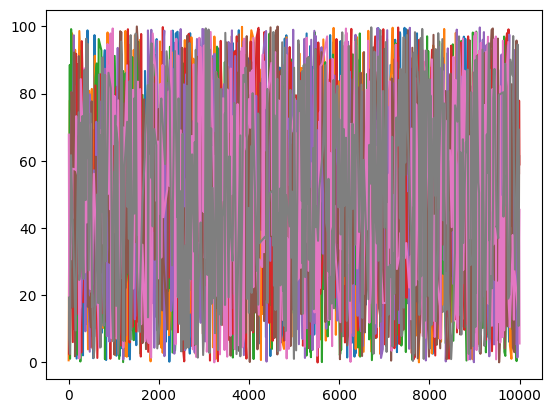

In [30]:
# 2. 按位置统计温度和湿度数据
# 筛选出温度和湿度数据，然后按位置和传感器类型分组，计算每个组的平均值 2分
# location_stats = data[data['SensorType'].groupby(data['SensorType']=='Temperature'||data['SensorType=='Humidity'])['Value'].mean().unstack()
# location_stats = data[data['SensorType'].isin(['Temperature', 'Humidity'])].groupby(['Location', 'SensorType'])['Value'].mean().unstack()
location_stats = data[data['SensorType'].isin(['Temperature', 'Humidity'])].groupby(['Location', 'SensorType'])['Value'].plot()
# 输出结果
print("每个位置的温度和湿度数据平均值:")
print(location_stats)

In [24]:
# 3. 数据清洗和异常值处理
# 标记异常值 3分
# print (help(data.dropna()))
data['is_abnormal'] = np.where(
    ((data['SensorType']=='Temperature') & ((data['Value'] < -10) | (data['Value'] > 50))) |
    ((data['SensorType']=='Humidity') & ((data['Value'] < 0) | (data['Value'] > 100))),
    True, False
)
# 输出异常值数量 2分
# print("异常值数量:", data['is_abnormal'].value_count())
print("异常值数量:", data['is_abnormal'].sum())
# 填补缺失值
# print (help(fillna))
# 使用前向填充和后向填充的方法填补缺失值 4分
data['Value'].fillna('ffill', inplace=True)
data['Value'].fillna('bfill', inplace=True)
# 保存清洗后的数据
# 删除用于标记异常值的列，并将清洗后的数据保存到新的CSV文件中 4分
# cleaned_data = data(data['Value']=['is_abnormal'])
cleaned_data = data.drop(columns=['is_abnormal'])
cleaned_data.to_csv('cleaned_sensor_data.csv', index=False)
print("数据清洗完成，已保存为 'cleaned_sensor_data.csv'")

异常值数量: 1011
数据清洗完成，已保存为 'cleaned_sensor_data.csv'
